11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 33ms/step - accuracy: 0.9561 - loss: 0.1455 - val_accuracy: 0.9865 - val_loss: 0.0489
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 32ms/step - accuracy: 0.9860 - loss: 0.0459 - val_accuracy: 0.9890 - val_loss: 0.0400
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 34ms/step - accuracy: 0.9893 - loss: 0.0336 - val_accuracy: 0.9834 - val_loss: 0.0502
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 61s 33ms/step - accuracy: 0.9919 - loss: 0.0247 - val_accuracy: 0.9912 - val_loss: 0.0332
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 35ms/step - accuracy: 0.9934 - loss: 0.0206 - val_accuracy: 0.9910 - val_loss: 0.0297
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9910 - loss: 0.0297
Test Accuracy: 0.9910
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


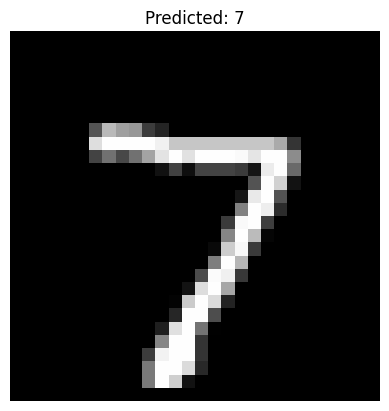

In [ ]:
# Import the Libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
# Load the MNIST Dataset
mnist= tf.keras.datasets.mnist
(X_train, y_train), (X_test, y_test)= mnist.load_data()
# Normalize Pixel Values to [0,1]
X_train, X_test= X_train/255.0, X_test/255.0
# Reshape the dataset to add channel dimension (needed for CNN)
X_train= X_train.reshape(-1,28,28,1)
X_test= X_test.reshape(-1,28,28,1)
# Define the CNN Model
model= models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)), # Convolutional Layer
    layers.MaxPooling2D((2,2)), # Pooling Layer
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.Flatten(), # Flatten for Dense Layers
    layers.Dense(64, activation='relu'), # Fully Connected Layers
    layers.Dense(10, activation='softmax') # Output Layer for 10 classes (digits 0-9)
])
# Compile the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
# Train the Model
model.fit(X_train, y_train, epochs=5, validation_data=(X_test,y_test))
# Evaluate the Model
test_loss, test_acc= model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}" )
# Make Predictions on test image
predictions= model.predict(X_test[:5])

# Display the first test image with its predicted label
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[0])}")
plt.axis('off')
plt.show()

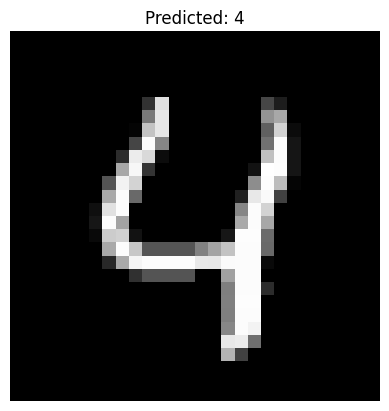

In [ ]:
plt.imshow(X_test[4].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {np.argmax(predictions[4])}")
plt.axis('off')
plt.show()